Text(0, 0.5, 'color_intensity')

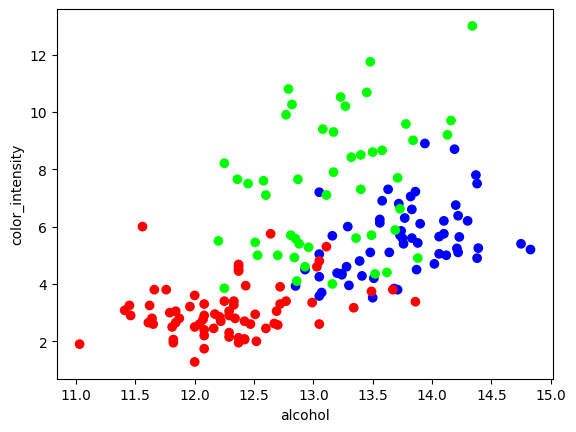

In [ ]:
from sklearn import datasets
import matplotlib.pyplot as plt

features = [0,9]

wine = datasets.load_wine()
data = wine.data[:,features]
targets = wine.target

plt.scatter(data[:,0],data[:,1], c=targets, cmap=plt.cm.brg)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])

Text(0, 0.5, 'color_intensity')

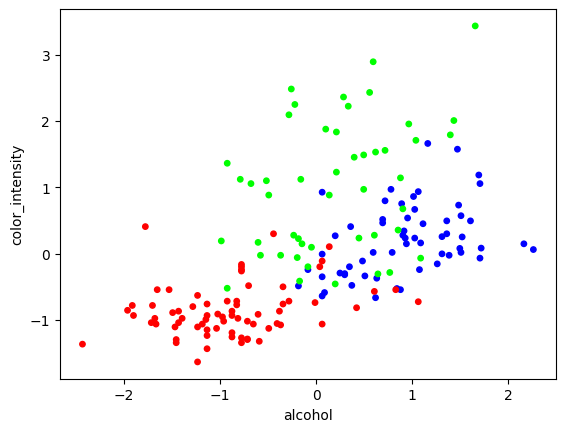

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(data)

plt.scatter(data[:,0], data[:,1], c=targets, cmap=plt.cm.brg, s=15)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])

In [ ]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
import numpy as np
def plot_boundary(X, y, model):
  x_min, x_max = X[:, 0].min()-0.1, X[:, 0].max()+0.1
  y_min, y_max = X[:, 1].min()-0.1, X[:, 1].max()+0.1

  spacing = min(x_max - x_min, y_max - y_min) / 100

  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing),
                       np.arange(y_min, y_max, spacing))

  data = np.hstack((XX.ravel().reshape(-1,1),
                    YY.ravel().reshape(-1,1)))

  # For multi-class problems
  db_prob = model(torch.Tensor(data).to(device) )
  clf = np.argmax(db_prob.cpu().data.numpy(), axis=-1)

  Z = clf.reshape(XX.shape)

  plt.contourf(XX, YY, Z, cmap=plt.cm.brg, alpha=0.5)
  plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=25, cmap=plt.cm.brg)

In [ ]:
print(data.shape[1])
print(targets.shape)
print(len(wine.target_names))

2
(178,)
3


In [ ]:
class WineClassifier(nn.Module):
  def __init__(self, input_layer, hidden_layer, out_layer):
    super(WineClassifier, self).__init__()
    self.l1 = nn.Linear(input_layer, hidden_layer)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hidden_layer, out_layer)
    self.sigmoid = nn.Sigmoid()

  def forward(self, X):
    y = self.relu(self.l1(X))
    y = self.sigmoid(self.l2(y))
    return y

input_layer = data.shape[1]
hidden_layer = 32
out_layer = len(wine.target_names)

net = WineClassifier(input_layer, hidden_layer, out_layer).to(device)

print(data.shape[1])

In [ ]:
X = torch.FloatTensor(data).to(device)
Y = torch.LongTensor(targets).to(device)

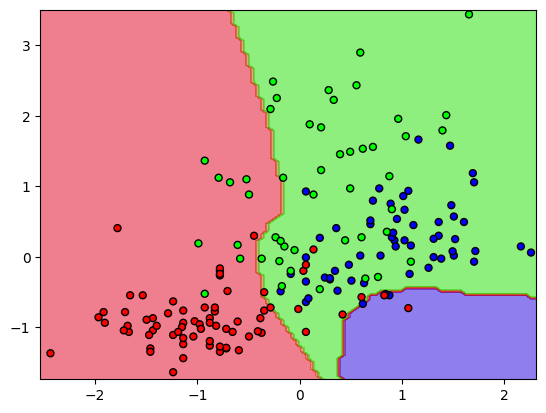

In [ ]:
plot_boundary(data,targets,net)

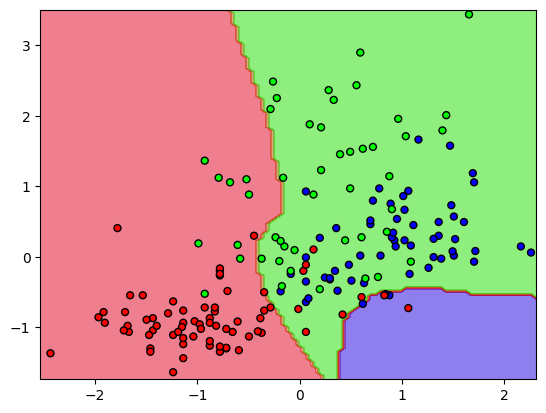

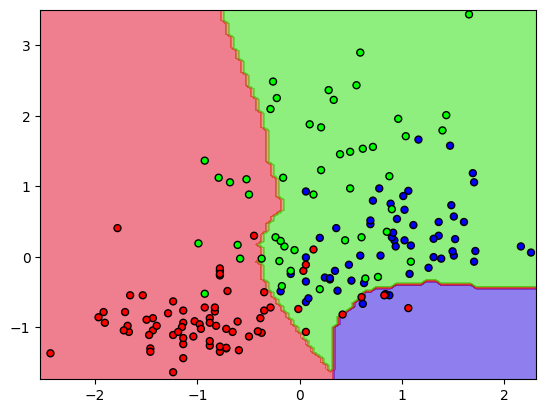

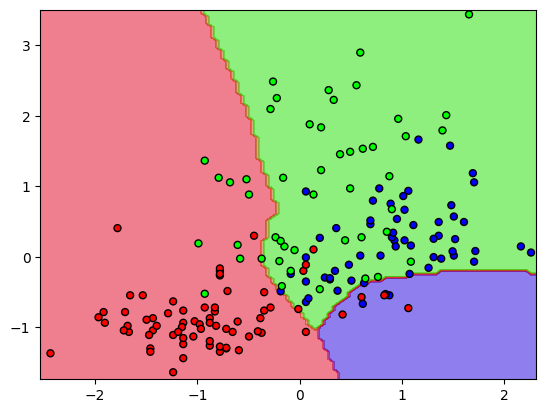

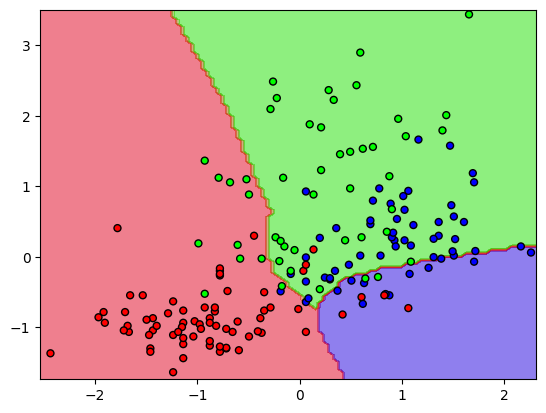

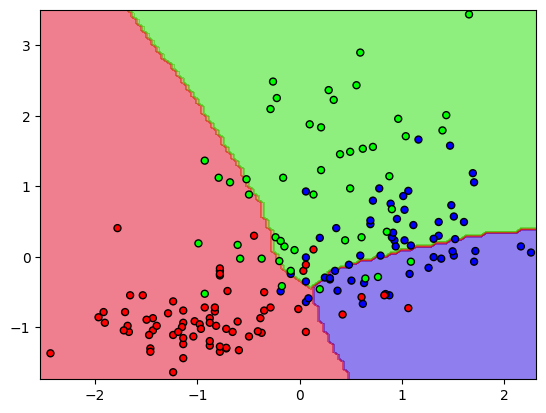

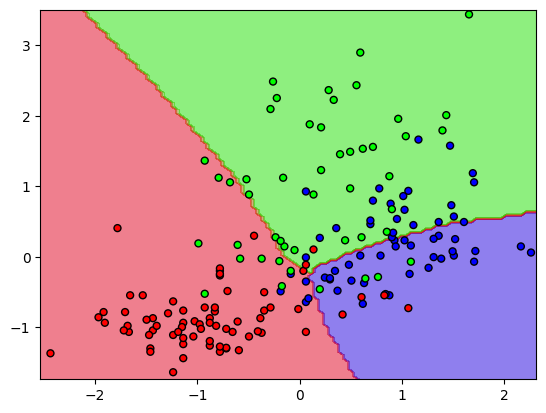

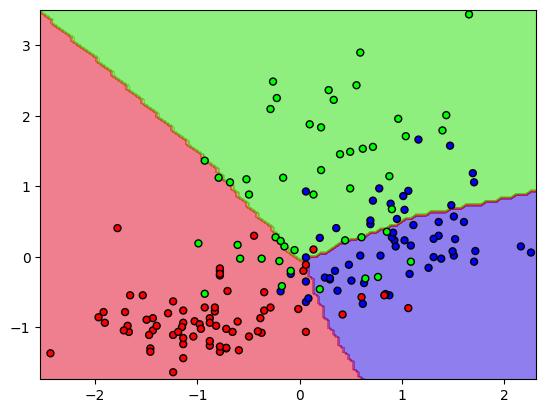

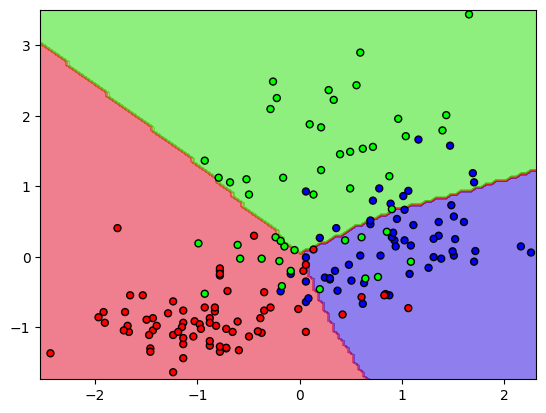

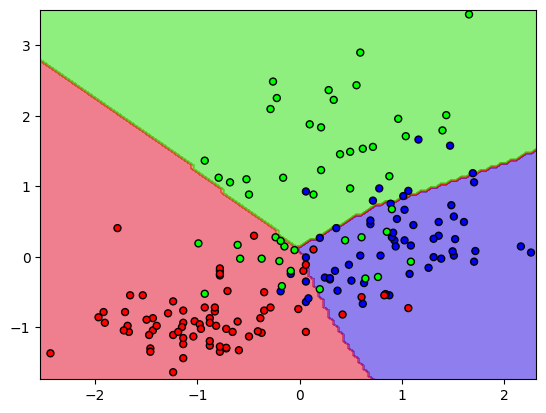

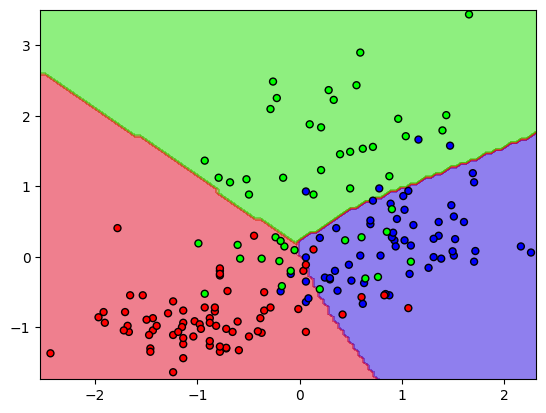

In [ ]:
from torch import optim
for i in range(100):

  criterion = nn.CrossEntropyLoss().to(device)

  optimizer = optim.SGD(net.parameters(), lr=1e-3)

  # Forward

  pred = net(X)
  loss = criterion(pred, Y)

  # Backpropagation

  loss.backward()
  optimizer.step()
  if i % 10 == 0:
    plt.figure()
    plot_boundary(data,targets,net)